# ARTI403 - Image Processing
## Lab 1: Basics of Programming with Python

**Name:** Mohammed Saeed Alamodi | **ID:** 2240009007

This notebook works through the tasks in the *Student Procedural Manual - Lab 1*.

### Setup
Create the `images/` folder and get the two sample images (`cameraman.tif` and `lena_gray_256.tif`) used below.

In [1]:
import os
from skimage import data
from PIL import Image

os.makedirs('images', exist_ok=True)

if not os.path.exists('images/cameraman.tif'):
    Image.fromarray(data.camera()).save('images/cameraman.tif')

if not os.path.exists('images/lena_gray_256.tif'):
    Image.fromarray(data.astronaut()[:, :, 0]).resize((256, 256)).save('images/lena_gray_256.tif')

print('Images ready:', os.listdir('images'))


Images ready: ['cameraman.tif', 'lena_gray_256.tif']


## Task #1: Exercise with Spyder

Exercise the two cheat sheets for Python practice in the resources section (NumPy cheat sheet and Python Basics cheat sheet). This task is done outside the notebook, directly in Spyder.

## Task #2: Loading and Visualizing Images

Loading/reading an image using OpenCV

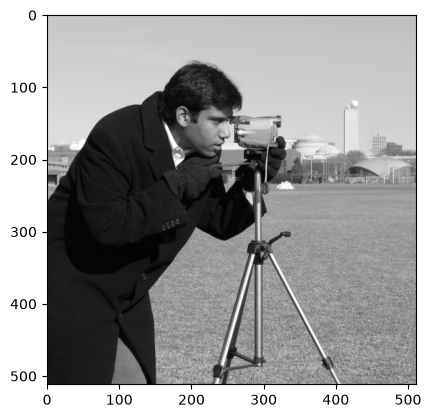

In [2]:
import cv2
img = cv2.imread('images/cameraman.tif') #Load the image data into a NumPy array

import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()


Loading/reading image using PIL

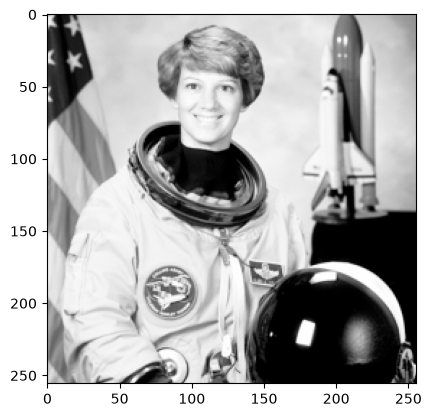

In [3]:
from PIL import Image
img2 = Image.open('images/lena_gray_256.tif') #load image into a PIL Image object

import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.imshow(img2, cmap = cm.Greys_r)
plt.show()


## Task #3: Image Storing

Saving image to disk using OpenCV

In [4]:
cv2.imwrite('new_image.jpg', img)


True

Saving an image to disk using PIL

In [5]:
img2.save('new_image2.jpg')


## Task #4: Display Image as an Array

In [6]:
print(img.shape) #Note: img1 loaded using open cv is a numpy array
print(img)


(512, 512, 3)
[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]


In [7]:
import numpy as np
# Convert the image to a NumPy array
img_array = np.array(img2)

# Print the array
print(img_array.shape)
print(img_array)


(256, 256)
[[144  90 114 ... 125 126 123]
 [202 180 188 ... 125 125 125]
 [233 225 219 ... 126 126 125]
 ...
 [186 187 181 ...  73  25   0]
 [186 183 173 ...  53   1   0]
 [184 178 162 ...  82  23   0]]


## Assessment
Perform different operations on the array using the NumPy library.

In [8]:
# Basic statistics on the pixel array
print('Min pixel value:', img_array.min())
print('Max pixel value:', img_array.max())
print('Mean pixel value:', img_array.mean())
print('Standard deviation:', img_array.std())


Min pixel value: 0
Max pixel value: 255
Mean pixel value: 141.568603515625
Standard deviation: 81.51174313795357


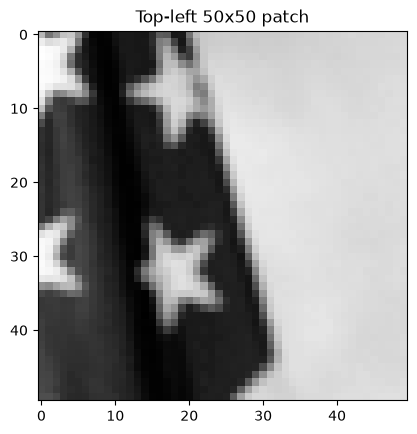

In [9]:
# Indexing and slicing: extract the top-left 50x50 patch
patch = img_array[:50, :50]
plt.imshow(patch, cmap=cm.Greys_r)
plt.title('Top-left 50x50 patch')
plt.show()


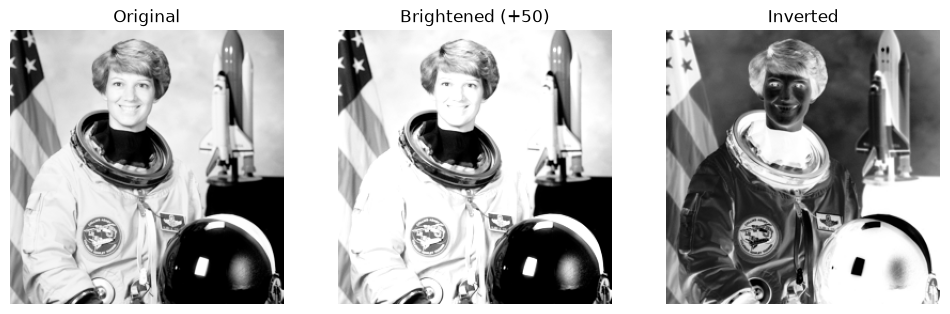

In [10]:
# Arithmetic operations: brighten and invert the image
brightened = np.clip(img_array.astype(np.int16) + 50, 0, 255).astype(np.uint8)
inverted = 255 - img_array

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_array, cmap=cm.Greys_r); axes[0].set_title('Original')
axes[1].imshow(brightened, cmap=cm.Greys_r); axes[1].set_title('Brightened (+50)')
axes[2].imshow(inverted, cmap=cm.Greys_r); axes[2].set_title('Inverted')
for ax in axes:
    ax.axis('off')
plt.show()


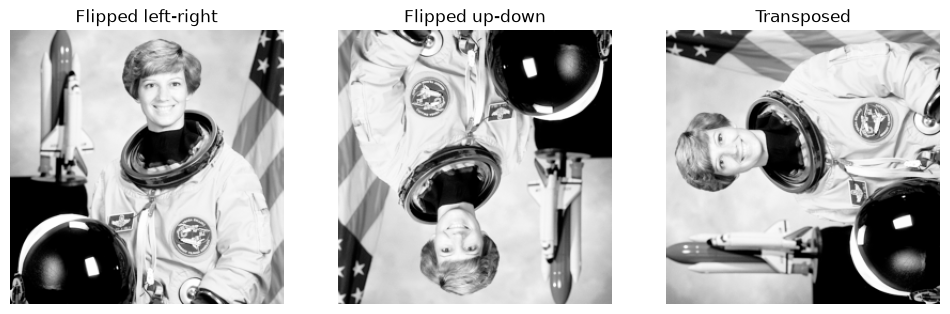

In [11]:
# Flipping and transposing the array
flipped_lr = np.fliplr(img_array)
flipped_ud = np.flipud(img_array)
transposed = img_array.T

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(flipped_lr, cmap=cm.Greys_r); axes[0].set_title('Flipped left-right')
axes[1].imshow(flipped_ud, cmap=cm.Greys_r); axes[1].set_title('Flipped up-down')
axes[2].imshow(transposed, cmap=cm.Greys_r); axes[2].set_title('Transposed')
for ax in axes:
    ax.axis('off')
plt.show()
